In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
import yaml
import time
from itertools import combinations
import gget
from scipy import sparse

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

sc.settings.verbosity = 3

# Load gene resources

In [2]:
%%time 
# === Load and filter GTF ===
gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)

exons = gtf[gtf['Feature'] == 'exon']
print(f"{exons.shape=}")
exons.head()

exons.shape=(1586950, 27)
CPU times: user 11.7 s, sys: 1.76 s, total: 13.4 s
Wall time: 13.6 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NaN,NaN,1.0,ENSE00003753029,1.0,NaN,NaN,ENSP00000484918.1,NaN
10,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,1.0,ENSE00002299440,2.0,NaN,NaN,ENSP00000483280.1,NaN
11,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,2.0,ENSE00003739295,1.0,NaN,NaN,ENSP00000483280.1,NaN
12,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,3.0,ENSE00003723764,1.0,NaN,NaN,ENSP00000483280.1,NaN
22,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1.0,NaN,1.0,ENSE00003736481,1.0,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [4]:
fpath = "../../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

print(f'\nN unique UNIPROT: {idf['uniprot'].nunique()}')

idf.head()

idf.shape=(110149, 11)

N unique UNIPROT: 73747


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [5]:
upath = "/scratch/indikar_root/indikar1/jrcwycy/hsc_temp/HUMAN_9606_idmapping_selected.tab.gz"

columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    'GeneID (EntrezGene)',
    'RefSeq',
    'GI',
    'PDB',
    'GO',
    'UniRef100',
    'UniRef90',
    'UniRef50',
    'UniParc',
    'PIR',
    'NCBI-taxon',
    'MIM',
    'UniGene',
    'PubMed',
    'EMBL',
    'EMBL-CDS',
    'Ensembl',
    'Ensembl_TRS',
    'Ensembl_PRO',
    'Additional PubMed',
]

udf = pd.read_csv(
    upath, 
    sep='\t',
    header=None,
    low_memory=False,
    names=columns,
)

keep_columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    # 'Ensembl',
    'Ensembl_TRS',
]

udf = udf[keep_columns]
udf = udf.assign(Ensembl_TRS=udf['Ensembl_TRS'].str.split(';')).explode('Ensembl_TRS')
udf['transcript_id'] = udf['Ensembl_TRS'].apply(lambda x: str(x).split(".")[0])
udf = udf.rename(columns={'UniProtKB-AC': 'uniprot'})

transcript_map = dict(zip(udf['transcript_id'].values, udf['uniprot'].values))

udf.head()

,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703
0,P31946,1433B_HUMAN,ENST00000372839.7,ENST00000372839
1,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335
1,P62258,1433E_HUMAN,ENST00000571732.5,ENST00000571732
1,P62258,1433E_HUMAN,ENST00000616643.3,ENST00000616643


In [6]:
gtf_sub = gtf[['transcript_id', 'transcript_name']].drop_duplicates()
gtf_sub = gtf_sub.dropna()
print(gtf_sub.shape)
gtf_sub.head()

(226005, 2)


,transcript_id,transcript_name
1,ENST00000618686,ENST00000618686
9,ENST00000613230,ENST00000613230
21,ENST00000400754,MAFIP-201
35,ENST00000612465,ENST00000612465
45,ENST00000616049,ENST00000616049


In [7]:
udf1 = pd.merge(udf, gtf_sub, how='left', on='transcript_id')
print(udf1.shape)

udf1 = udf1.dropna(subset='transcript_name')

print(udf1.shape)
udf1.head()

(246523, 5)
(78415, 5)


,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id,transcript_name
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703,YWHAB-201
2,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335,YWHAE-201
6,Q04917,1433F_HUMAN,ENST00000248975.6,ENST00000248975,YWHAH-201
7,P61981,1433G_HUMAN,ENST00000307630.5,ENST00000307630,YWHAG-201
8,P31947,1433S_HUMAN,ENST00000339276.6,ENST00000339276,SFN-201


In [8]:
print(udf['uniprot'].nunique())
print(udf1['uniprot'].nunique())

205003
78415


In [9]:
transcript_map = dict(zip(udf1['transcript_name'].values, udf1['uniprot'].values))

In [10]:
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639


# Load gene data

In [11]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
gdata = sc.read_h5ad(path)
gdata

CPU times: user 498 ms, sys: 1.68 s, total: 2.18 s
Wall time: 5.31 s


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Load isoform data

In [12]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/isoforms.h5ad"
adata = sc.read_h5ad(path)
adata.var.set_index('transcript_name', inplace=True)
print(adata)
adata.var.head()

AnnData object with n_obs × n_vars = 19858 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'
CPU times: user 346 ms, sys: 359 ms, total: 705 ms
Wall time: 1.74 s


,gene_id,gene_name,gene_type,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB
transcript_name,,,,,,,,,
ARF5-201,ENSG00000004059,ARF5,protein_coding,protein_coding,chr7,127588410,127591700,ENST00000000233,P84085
M6PR-201,ENSG00000003056,M6PR,protein_coding,protein_coding,chr12,8940360,8949645,ENST00000000412,P20645
ESRRA-201,ENSG00000173153,ESRRA,protein_coding,protein_coding,chr11,64305523,64316743,ENST00000000442,P11474
FKBP4-201,ENSG00000004478,FKBP4,protein_coding,protein_coding,chr12,2794969,2805423,ENST00000001008,Q02790
CYP26B1-201,ENSG00000003137,CYP26B1,protein_coding,protein_coding,chr2,72129237,72147862,ENST00000001146,Q9NR63


In [13]:
%%time

print(f"Initial number of cells in adata: {adata.n_obs}")
print(f"Number of cells in gdata: {gdata.n_obs}")

# Subset adata to those present in bdata
cells_to_keep = adata.obs_names.isin(gdata.obs_names)
print(f"Number of cells in adata after filtering by gdata: {cells_to_keep.sum()}")

adata = adata[cells_to_keep, :].copy()
print(f"Final number of cells in adata: {adata.n_obs}")

# Sort adata and bdata to the same order (shared cells only)
shared_cells = gdata.obs_names.intersection(adata.obs_names)
print(f"Number of shared cells: {len(shared_cells)}")

# Sort both AnnData objects
adata = adata[shared_cells, :].copy()
gdata_sorted = gdata[shared_cells, :].copy()

# Assert same order
assert all(adata.obs_names == gdata_sorted.obs_names), "Cell ordering does not match!"
print("Cell ordering is identical between adata and bdata (shared cells).")
adata

Initial number of cells in adata: 19858
Number of cells in gdata: 16296
Number of cells in adata after filtering by gdata: 16296
Final number of cells in adata: 16296
Number of shared cells: 16296
Cell ordering is identical between adata and bdata (shared cells).
CPU times: user 1.67 s, sys: 2.99 s, total: 4.67 s
Wall time: 4.71 s


AnnData object with n_obs × n_vars = 16296 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'

## Merge

Before merge: adata.obs columns = ['dataset', 'n_reads', 'n_transcripts']
After merge: adata.obs columns = ['dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata']
AnnData object with n_obs × n_vars = 16296 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'
    uns: 'leiden_split_colors', 'dataset_colors', 'pooled_condition_colors', 'umap'
    obsm: 'X_umap'


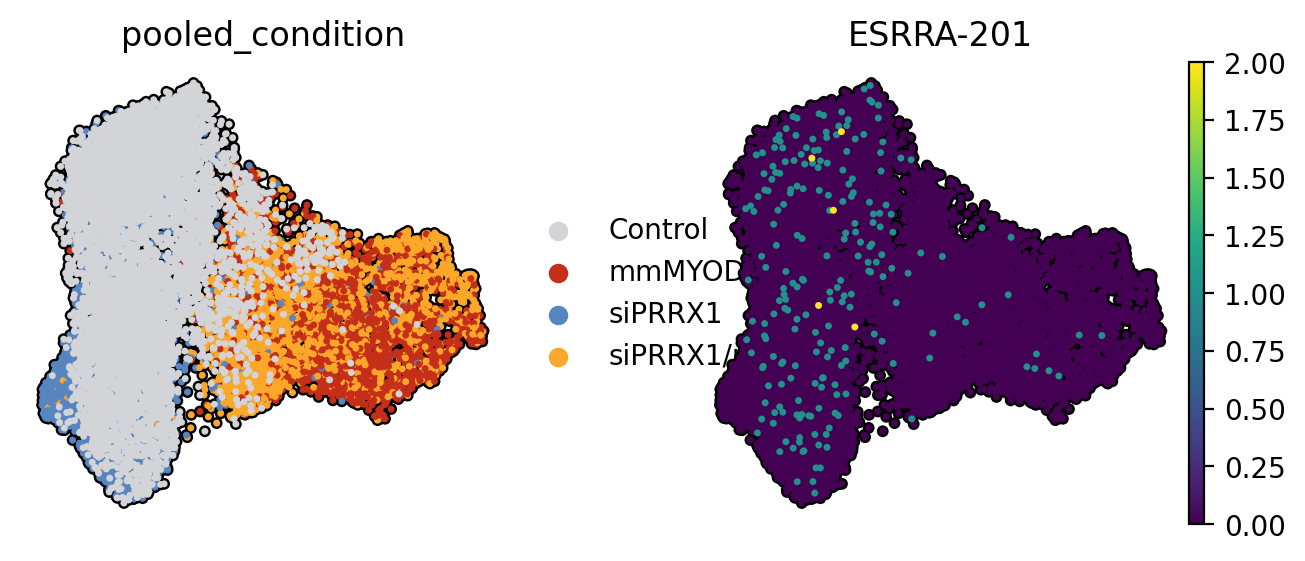

CPU times: user 852 ms, sys: 29.9 ms, total: 881 ms
Wall time: 925 ms


In [14]:
%%time

obs_columns = [
    'leiden_split',
    'pooled_condition',
    'phase',
    'dataset',
]

print(f"Before merge: adata.obs columns = {list(adata.obs.columns)}")

# Subset bdata.obs to the needed columns
df_merge = gdata.obs[obs_columns].copy()
df_merge.index.name = "cell"

# Merge by index (obs_names)
adata.obs = adata.obs.merge(df_merge, left_index=True, right_index=True, suffixes=('', '_gdata'))

print(f"After merge: adata.obs columns = {list(adata.obs.columns)}")

# Add uns
adata.uns['leiden_split_colors'] = gdata.uns['leiden_split_colors'].copy()
adata.uns['dataset_colors'] = gdata.uns['dataset_colors'].copy()
adata.uns['pooled_condition_colors'] = gdata.uns['pooled_condition_colors'].copy()

# Merge embeddings
adata.obsm['X_umap'] = gdata.obsm['X_umap'].copy()
adata.uns['umap'] = gdata.uns['umap'].copy()

print(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    ncols=2,
    sort_order=True,
    color=['pooled_condition', 'ESRRA-201'],
    size=25,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

## Normalize counts

In [15]:
sc.pp.filter_genes(adata, min_counts=20)

adata.layers['counts'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 31726 genes that are detected in less than 20 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 16296 × 57844
    obs: 'dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB', 'n_counts'
    uns: 'leiden_split_colors', 'dataset_colors', 'pooled_condition_colors', 'umap', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

In [16]:
# group cells by cell cycle phase

# Create a collapsed phase column
adata.obs['phase_grouped'] = adata.obs['phase'].replace({
    'G1': 'G1S',
    'S': 'G1S',
    'G2M': 'G2M'
})

# Create the combined grouping column
adata.obs['condition_phase'] = (
    adata.obs['pooled_condition'].astype(str) + '_' +
    adata.obs['phase_grouped'].astype(str)
)

adata.obs["condition_phase"].value_counts(sort=False)

/tmp/ipykernel_1592878/3485333207.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['phase_grouped'] = adata.obs['phase'].replace({


condition_phase
siPRRX1/mmMYOD1_G2M     818
mmMYOD1_G1S            1924
siPRRX1/mmMYOD1_G1S    2638
siPRRX1_G2M            1485
mmMYOD1_G2M             331
siPRRX1_G1S            2198
Control_G2M            2980
Control_G1S            3922
Name: count, dtype: int64

# Pseudobulk

In [58]:
%%time 

adata.X = adata.layers['counts'].copy()

aggdata = sc.get.aggregate(
    adata, 
    by='condition_phase',
    func='sum',
    axis=0,
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
sc.pp.log1p(aggdata)

aggdata.layers['log_norm'] = aggdata.X.copy()

aggdata


df = aggdata.to_df(layer='sum').T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],#, 'transcript_name']],
    how='left',
    left_index=True,
    right_index=True,
)

df = df.reset_index(names='transcript_name')
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
# df['uniprot'] = df['transcript_name'].map(transcript_map)
df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
print(f"{df.shape=}")
df.head()

normalizing counts per cell
    finished (0:00:00)
df.shape=(57844, 15)
CPU times: user 438 ms, sys: 355 ms, total: 794 ms
Wall time: 808 ms


,transcript_name,Control_G1S,Control_G2M,mmMYOD1_G1S,mmMYOD1_G2M,siPRRX1/mmMYOD1_G1S,siPRRX1/mmMYOD1_G2M,siPRRX1_G1S,siPRRX1_G2M,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-203,6.0,3.0,4.0,2.0,9.0,4.0,11.0,5.0,44.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN
1,A1BG-204,3942.0,2224.0,853.0,141.0,1321.0,328.0,1877.0,856.0,11542.0,A1BG,protein_coding,retained_intron,False,NaN
2,A1BG-AS1-202,18.0,16.0,4.0,0.0,14.0,3.0,14.0,8.0,77.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
3,A1BG-AS1-203,14.0,5.0,2.0,0.0,10.0,2.0,3.0,5.0,41.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-204,51.0,45.0,36.0,5.0,55.0,12.0,45.0,19.0,268.0,A1BG-AS1,lncRNA,lncRNA,False,NaN


In [59]:
# rename for ease of use downstream
df.columns = df.columns.str.replace('siPRRX1/mmMYOD1', 'HYB', regex=False)

df.head()

,transcript_name,Control_G1S,Control_G2M,mmMYOD1_G1S,mmMYOD1_G2M,HYB_G1S,HYB_G2M,siPRRX1_G1S,siPRRX1_G2M,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-203,6.0,3.0,4.0,2.0,9.0,4.0,11.0,5.0,44.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN
1,A1BG-204,3942.0,2224.0,853.0,141.0,1321.0,328.0,1877.0,856.0,11542.0,A1BG,protein_coding,retained_intron,False,NaN
2,A1BG-AS1-202,18.0,16.0,4.0,0.0,14.0,3.0,14.0,8.0,77.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
3,A1BG-AS1-203,14.0,5.0,2.0,0.0,10.0,2.0,3.0,5.0,41.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-204,51.0,45.0,36.0,5.0,55.0,12.0,45.0,19.0,268.0,A1BG-AS1,lncRNA,lncRNA,False,NaN


## Filter for cell cycle transcripts

In [60]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(f'Total regev genes: {len(regev_genes)}')

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

regev_genes = [g for g in regev_genes if g in adata.var['gene_name'].unique()]
print(f'\tDetected in adata: {len(regev_genes)}')


# GO
cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
cc_genes = cdf['gene_name'].unique()
print(f'\nTotal GO cell cycle genes: {len(cc_genes)}')
cc_genes = [g for g in cc_genes if g in adata.var['gene_name'].unique()]
print(f'\tDetected in adata: {len(cc_genes)}')


all_cc_genes = list(set(regev_genes) | set(cc_genes))
print(f'\nGenes in combined list: {len(all_cc_genes)}')

Total regev genes: 97
	Detected in adata: 94

Total GO cell cycle genes: 142
	Detected in adata: 115

Genes in combined list: 205


In [61]:
cdf = df[df['gene_name'].isin(all_cc_genes)].copy()

# keep G1S
phase_to_remove = 'G2M'

# other_cols = ['transcript_name', 'total_transcript', 'gene_name', 'gene_type', 'transcript_type', 'is_tf', 'uniprot']

cols_to_remove = [col for col in cdf.columns if phase_to_remove in col]
print(len(cols_to_remove))

cdf = cdf.drop(columns=cols_to_remove)


print(cdf.shape)
print(f'N unique cell cycle genes: {cdf['gene_name'].nunique()}')
print(f'N unique cell cycle transcripts: {cdf['transcript_name'].nunique()}')

cdf.head()

4
(822, 11)
N unique cell cycle genes: 205
N unique cell cycle transcripts: 822


,transcript_name,Control_G1S,mmMYOD1_G1S,HYB_G1S,siPRRX1_G1S,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
119,ABCB1-211,6.0,26.0,46.0,3.0,97.0,ABCB1,protein_coding,protein_coding,False,A4D1D2
641,ACVR1B-201,7.0,67.0,74.0,61.0,284.0,ACVR1B,protein_coding,protein_coding,False,P36896
642,ACVR1B-205,0.0,46.0,83.0,66.0,276.0,ACVR1B,protein_coding,protein_coding,False,P36896
1558,AMBRA1-201,0.0,5.0,15.0,5.0,32.0,AMBRA1,protein_coding,protein_coding,False,Q9C0C7
1559,AMBRA1-205,12.0,17.0,22.0,19.0,129.0,AMBRA1,protein_coding,protein_coding,False,E9PL55


In [62]:
%%time
pdf = cdf.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name', observed=True)['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name', observed=True)['uniprot'].transform('nunique')

phase = 'G1S'

groups = [f'Control_{phase}', f'mmMYOD1_{phase}', f'siPRRX1_{phase}', f'HYB_{phase}']

# add grouped expression counts
grouped = pdf.groupby('gene_name', observed=True)[groups].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in groups:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

pdf.head()

CPU times: user 15.8 ms, sys: 755 μs, total: 16.5 ms
Wall time: 20.6 ms


,transcript_name,Control_G1S,mmMYOD1_G1S,HYB_G1S,siPRRX1_G1S,total_transcript,gene_name,gene_type,transcript_type,is_tf,...,n_protiens,Control_G1S_sum,mmMYOD1_G1S_sum,siPRRX1_G1S_sum,HYB_G1S_sum,total_gene,Control_G1S_pct,mmMYOD1_G1S_pct,siPRRX1_G1S_pct,HYB_G1S_pct
0,ABCB1-211,6.0,26.0,46.0,3.0,97.0,ABCB1,protein_coding,protein_coding,False,...,1,6.0,26.0,3.0,46.0,81.0,1.000000,1.000000,1.000000,1.000000
1,ACVR1B-201,7.0,67.0,74.0,61.0,284.0,ACVR1B,protein_coding,protein_coding,False,...,1,7.0,113.0,127.0,157.0,404.0,1.000000,0.592920,0.480315,0.471338
2,ACVR1B-205,0.0,46.0,83.0,66.0,276.0,ACVR1B,protein_coding,protein_coding,False,...,1,7.0,113.0,127.0,157.0,404.0,0.000000,0.407080,0.519685,0.528662
3,AMBRA1-201,0.0,5.0,15.0,5.0,32.0,AMBRA1,protein_coding,protein_coding,False,...,2,26.0,147.0,132.0,203.0,508.0,0.000000,0.034014,0.037879,0.073892
4,AMBRA1-205,12.0,17.0,22.0,19.0,129.0,AMBRA1,protein_coding,protein_coding,False,...,2,26.0,147.0,132.0,203.0,508.0,0.461538,0.115646,0.143939,0.108374


# Dominance

In [63]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)




cols = [x + '_pct' for x in groups]

for col in cols:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,Control_G1S,mmMYOD1_G1S,HYB_G1S,siPRRX1_G1S,total_transcript,gene_name,gene_type,transcript_type,is_tf,...,HYB_G1S_sum,total_gene,Control_G1S_pct,mmMYOD1_G1S_pct,siPRRX1_G1S_pct,HYB_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,siPRRX1_G1S_pct_top,HYB_G1S_pct_top
0,ABCB1-211,6.0,26.0,46.0,3.0,97.0,ABCB1,protein_coding,protein_coding,False,...,46.0,81.0,1.000000,1.000000,1.000000,1.000000,ABCB1-211,ABCB1-211,ABCB1-211,ABCB1-211
1,ACVR1B-201,7.0,67.0,74.0,61.0,284.0,ACVR1B,protein_coding,protein_coding,False,...,157.0,404.0,1.000000,0.592920,0.480315,0.471338,ACVR1B-201,ACVR1B-201,ACVR1B-205,ACVR1B-205
2,ACVR1B-205,0.0,46.0,83.0,66.0,276.0,ACVR1B,protein_coding,protein_coding,False,...,157.0,404.0,0.000000,0.407080,0.519685,0.528662,ACVR1B-201,ACVR1B-201,ACVR1B-205,ACVR1B-205
3,AMBRA1-201,0.0,5.0,15.0,5.0,32.0,AMBRA1,protein_coding,protein_coding,False,...,203.0,508.0,0.000000,0.034014,0.037879,0.073892,AMBRA1-209,AMBRA1-209,AMBRA1-209,AMBRA1-209
4,AMBRA1-205,12.0,17.0,22.0,19.0,129.0,AMBRA1,protein_coding,protein_coding,False,...,203.0,508.0,0.461538,0.115646,0.143939,0.108374,AMBRA1-209,AMBRA1-209,AMBRA1-209,AMBRA1-209


In [64]:
pdf.columns

Index(['transcript_name', 'Control_G1S', 'mmMYOD1_G1S', 'HYB_G1S',
       'siPRRX1_G1S', 'total_transcript', 'gene_name', 'gene_type',
       'transcript_type', 'is_tf', 'uniprot', 'n_isoforms', 'n_protiens',
       'Control_G1S_sum', 'mmMYOD1_G1S_sum', 'siPRRX1_G1S_sum', 'HYB_G1S_sum',
       'total_gene', 'Control_G1S_pct', 'mmMYOD1_G1S_pct', 'siPRRX1_G1S_pct',
       'HYB_G1S_pct', 'Control_G1S_pct_top', 'mmMYOD1_G1S_pct_top',
       'siPRRX1_G1S_pct_top', 'HYB_G1S_pct_top'],
      dtype='object')

In [65]:
# just compare Control and mmMYOD1

cond_cols = [col for col in pdf.columns if ('HYB' in col) or ('siPRRX1' in col)]
print(len(cond_cols))

pdf = pdf.drop(columns=cond_cols)

print(pdf.shape)
pdf.head()

8
(822, 18)


,transcript_name,Control_G1S,mmMYOD1_G1S,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot,n_isoforms,n_protiens,Control_G1S_sum,mmMYOD1_G1S_sum,total_gene,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top
0,ABCB1-211,6.0,26.0,97.0,ABCB1,protein_coding,protein_coding,False,A4D1D2,1,1,6.0,26.0,81.0,1.000000,1.000000,ABCB1-211,ABCB1-211
1,ACVR1B-201,7.0,67.0,284.0,ACVR1B,protein_coding,protein_coding,False,P36896,2,1,7.0,113.0,404.0,1.000000,0.592920,ACVR1B-201,ACVR1B-201
2,ACVR1B-205,0.0,46.0,276.0,ACVR1B,protein_coding,protein_coding,False,P36896,2,1,7.0,113.0,404.0,0.000000,0.407080,ACVR1B-201,ACVR1B-201
3,AMBRA1-201,0.0,5.0,32.0,AMBRA1,protein_coding,protein_coding,False,Q9C0C7,5,2,26.0,147.0,508.0,0.000000,0.034014,AMBRA1-209,AMBRA1-209
4,AMBRA1-205,12.0,17.0,129.0,AMBRA1,protein_coding,protein_coding,False,E9PL55,5,2,26.0,147.0,508.0,0.461538,0.115646,AMBRA1-209,AMBRA1-209


In [66]:
pdf['is_switch'] = pdf['Control_G1S_pct_top'] != pdf['mmMYOD1_G1S_pct_top']
pdf.head()

,transcript_name,Control_G1S,mmMYOD1_G1S,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot,n_isoforms,n_protiens,Control_G1S_sum,mmMYOD1_G1S_sum,total_gene,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch
0,ABCB1-211,6.0,26.0,97.0,ABCB1,protein_coding,protein_coding,False,A4D1D2,1,1,6.0,26.0,81.0,1.000000,1.000000,ABCB1-211,ABCB1-211,False
1,ACVR1B-201,7.0,67.0,284.0,ACVR1B,protein_coding,protein_coding,False,P36896,2,1,7.0,113.0,404.0,1.000000,0.592920,ACVR1B-201,ACVR1B-201,False
2,ACVR1B-205,0.0,46.0,276.0,ACVR1B,protein_coding,protein_coding,False,P36896,2,1,7.0,113.0,404.0,0.000000,0.407080,ACVR1B-201,ACVR1B-201,False
3,AMBRA1-201,0.0,5.0,32.0,AMBRA1,protein_coding,protein_coding,False,Q9C0C7,5,2,26.0,147.0,508.0,0.000000,0.034014,AMBRA1-209,AMBRA1-209,False
4,AMBRA1-205,12.0,17.0,129.0,AMBRA1,protein_coding,protein_coding,False,E9PL55,5,2,26.0,147.0,508.0,0.461538,0.115646,AMBRA1-209,AMBRA1-209,False


In [67]:
print(pdf['is_switch'].sum())

271


In [68]:
sdf = pdf[pdf['is_switch']].copy()


print(f'N unique genes: {sdf['gene_name'].nunique()}')

print(sdf.shape)
sdf.head()

N unique genes: 57
(271, 19)


,transcript_name,Control_G1S,mmMYOD1_G1S,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot,n_isoforms,n_protiens,Control_G1S_sum,mmMYOD1_G1S_sum,total_gene,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch
18,APP-201,0.0,17.0,111.0,APP,protein_coding,protein_coding,False,A0A140VJC8,8,3,562.0,166.0,1161.0,0.000000,0.102410,APP-204,APP-211,True
19,APP-202,12.0,3.0,38.0,APP,protein_coding,protein_coding,False,P05067,8,3,562.0,166.0,1161.0,0.021352,0.018072,APP-204,APP-211,True
20,APP-204,335.0,10.0,590.0,APP,protein_coding,protein_coding,False,P05067,8,3,562.0,166.0,1161.0,0.596085,0.060241,APP-204,APP-211,True
21,APP-210,32.0,24.0,194.0,APP,protein_coding,protein_coding,False,H7C0V9,8,3,562.0,166.0,1161.0,0.056940,0.144578,APP-204,APP-211,True
22,APP-211,100.0,98.0,629.0,APP,protein_coding,retained_intron,False,NaN,8,3,562.0,166.0,1161.0,0.177936,0.590361,APP-204,APP-211,True


In [69]:
print(", ".join(sorted(sdf['gene_name'].unique())))

APP, BRIP1, CAMK2A, CASP8AP2, CCDC57, CCNE2, CCNY, CDC25C, CDC34, CDC7, CDCA2, CDCA7, CDK1, CDK6, CENPA, CENPE, CENPF, CHEK1, CHEK2, CKAP5, CSDE1, CUL2, DNM2, E2F8, ECT2, EZH2, FBXL7, GAS2L3, HMMR, ITGB1, KDM8, KIF11, KIF20B, KIF2C, MASTL, MCM4, MTA3, NUF2, NUSAP1, PBX1, PHF8, PLK3, POLE, PPM1D, PSRC1, RAD51AP1, RCC1, RPS6KB1, RTEL1, SPDYA, SYCP2, TACC3, TAF2, TERF2, TPD52L1, UBE2A, USP37


In [70]:
sdf[sdf['gene_name'] == 'CDK6']

,transcript_name,Control_G1S,mmMYOD1_G1S,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot,n_isoforms,n_protiens,Control_G1S_sum,mmMYOD1_G1S_sum,total_gene,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch
190,CDK6-201,38.0,1613.0,5849.0,CDK6,protein_coding,protein_coding,False,Q00534,2,1,393.0,1661.0,4994.0,0.096692,0.971102,CDK6-202,CDK6-201,True
191,CDK6-202,355.0,48.0,816.0,CDK6,protein_coding,protein_coding,False,Q00534,2,1,393.0,1661.0,4994.0,0.903308,0.028898,CDK6-202,CDK6-201,True


In [71]:
cols_to_keep = [
    'transcript_name', 'gene_name', 'gene_type', 'is_tf', 'uniprot',
    'Control_G1S_sum', 'mmMYOD1_G1S_sum',
    'Control_G1S_pct', 'mmMYOD1_G1S_pct',
    'Control_G1S_pct_top', 'mmMYOD1_G1S_pct_top', 
    'is_switch',
]

sdf = sdf[cols_to_keep]
sdf.head()

,transcript_name,gene_name,gene_type,is_tf,uniprot,Control_G1S_sum,mmMYOD1_G1S_sum,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch
18,APP-201,APP,protein_coding,False,A0A140VJC8,562.0,166.0,0.000000,0.102410,APP-204,APP-211,True
19,APP-202,APP,protein_coding,False,P05067,562.0,166.0,0.021352,0.018072,APP-204,APP-211,True
20,APP-204,APP,protein_coding,False,P05067,562.0,166.0,0.596085,0.060241,APP-204,APP-211,True
21,APP-210,APP,protein_coding,False,H7C0V9,562.0,166.0,0.056940,0.144578,APP-204,APP-211,True
22,APP-211,APP,protein_coding,False,NaN,562.0,166.0,0.177936,0.590361,APP-204,APP-211,True


In [72]:
sdf['Control_uniprot'] = sdf['uniprot'].where(
    sdf['Control_G1S_pct_top'] == sdf['transcript_name']
)

sdf['mmMYOD1_uniprot'] = sdf['uniprot'].where(
    sdf['mmMYOD1_G1S_pct_top'] == sdf['transcript_name']
)

sdf.head()

,transcript_name,gene_name,gene_type,is_tf,uniprot,Control_G1S_sum,mmMYOD1_G1S_sum,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch,Control_uniprot,mmMYOD1_uniprot
18,APP-201,APP,protein_coding,False,A0A140VJC8,562.0,166.0,0.000000,0.102410,APP-204,APP-211,True,NaN,NaN
19,APP-202,APP,protein_coding,False,P05067,562.0,166.0,0.021352,0.018072,APP-204,APP-211,True,NaN,NaN
20,APP-204,APP,protein_coding,False,P05067,562.0,166.0,0.596085,0.060241,APP-204,APP-211,True,P05067,NaN
21,APP-210,APP,protein_coding,False,H7C0V9,562.0,166.0,0.056940,0.144578,APP-204,APP-211,True,NaN,NaN
22,APP-211,APP,protein_coding,False,NaN,562.0,166.0,0.177936,0.590361,APP-204,APP-211,True,NaN,NaN


In [73]:
sdf['uniprot_match'] = (
    (sdf['Control_uniprot'] == sdf['mmMYOD1_uniprot']) |
    (sdf['Control_uniprot'].isna() & sdf['mmMYOD1_uniprot'].isna())
)

sdf.head()

,transcript_name,gene_name,gene_type,is_tf,uniprot,Control_G1S_sum,mmMYOD1_G1S_sum,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch,Control_uniprot,mmMYOD1_uniprot,uniprot_match
18,APP-201,APP,protein_coding,False,A0A140VJC8,562.0,166.0,0.000000,0.102410,APP-204,APP-211,True,NaN,NaN,True
19,APP-202,APP,protein_coding,False,P05067,562.0,166.0,0.021352,0.018072,APP-204,APP-211,True,NaN,NaN,True
20,APP-204,APP,protein_coding,False,P05067,562.0,166.0,0.596085,0.060241,APP-204,APP-211,True,P05067,NaN,False
21,APP-210,APP,protein_coding,False,H7C0V9,562.0,166.0,0.056940,0.144578,APP-204,APP-211,True,NaN,NaN,True
22,APP-211,APP,protein_coding,False,NaN,562.0,166.0,0.177936,0.590361,APP-204,APP-211,True,NaN,NaN,True


In [74]:
sdf['uniprot_match'].value_counts()

uniprot_match
True     203
False     68
Name: count, dtype: int64

In [75]:
jdf = sdf[~sdf['uniprot_match']].copy()

print(jdf.shape)
display(jdf.head())

print(", ".join(sorted(jdf['gene_name'].unique())))

(68, 15)


,transcript_name,gene_name,gene_type,is_tf,uniprot,Control_G1S_sum,mmMYOD1_G1S_sum,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch,Control_uniprot,mmMYOD1_uniprot,uniprot_match
20,APP-204,APP,protein_coding,False,P05067,562.0,166.0,0.596085,0.060241,APP-204,APP-211,True,P05067,NaN,False
61,BRIP1-201,BRIP1,protein_coding,False,Q9BX63,113.0,268.0,0.168142,0.350746,BRIP1-225,BRIP1-201,True,NaN,Q9BX63,False
112,CASP8AP2-202,CASP8AP2,protein_coding,False,A0A096LP21,173.0,313.0,0.872832,0.239617,CASP8AP2-202,CASP8AP2-201,True,A0A096LP21,NaN,False
142,CCNE2-201,CCNE2,protein_coding,False,O96020,28.0,83.0,1.000000,0.204819,CCNE2-201,CCNE2-205,True,O96020,NaN,False
144,CCNE2-205,CCNE2,protein_coding,False,O96020,28.0,83.0,0.000000,0.518072,CCNE2-201,CCNE2-205,True,NaN,O96020,False


APP, BRIP1, CASP8AP2, CCNE2, CCNY, CDC25C, CDC34, CDC7, CDCA2, CDK1, CDK6, CENPE, CHEK2, CUL2, DNM2, ECT2, EZH2, FBXL7, GAS2L3, HMMR, ITGB1, KDM8, KIF11, KIF20B, KIF2C, MASTL, MCM4, MTA3, NUF2, NUSAP1, PHF8, POLE, PPM1D, RAD51AP1, RCC1, RTEL1, SYCP2, TACC3, TERF2, TPD52L1, UBE2A, USP37


In [76]:
jdf[jdf['gene_name'] == 'CDK1']

,transcript_name,gene_name,gene_type,is_tf,uniprot,Control_G1S_sum,mmMYOD1_G1S_sum,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch,Control_uniprot,mmMYOD1_uniprot,uniprot_match
185,CDK1-203,CDK1,protein_coding,False,P06493,421.0,272.0,0.000000,0.878676,CDK1-204,CDK1-203,True,NaN,P06493,False
186,CDK1-204,CDK1,protein_coding,False,A0A024QZP7,421.0,272.0,0.897862,0.110294,CDK1-204,CDK1-203,True,A0A024QZP7,NaN,False


In [77]:
jdf[jdf['gene_name'] == 'ITGB1']

,transcript_name,gene_name,gene_type,is_tf,uniprot,Control_G1S_sum,mmMYOD1_G1S_sum,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch,Control_uniprot,mmMYOD1_uniprot,uniprot_match
440,ITGB1-220,ITGB1,protein_coding,False,P05556,21252.0,748.0,0.890693,0.096257,ITGB1-220,ITGB1-226,True,P05556,NaN,False
442,ITGB1-226,ITGB1,protein_coding,False,C9JPK5,21252.0,748.0,0.012893,0.278075,ITGB1-220,ITGB1-226,True,NaN,C9JPK5,False


In [79]:
jdf[jdf['gene_name'] == 'CHEK2']

,transcript_name,gene_name,gene_type,is_tf,uniprot,Control_G1S_sum,mmMYOD1_G1S_sum,Control_G1S_pct,mmMYOD1_G1S_pct,Control_G1S_pct_top,mmMYOD1_G1S_pct_top,is_switch,Control_uniprot,mmMYOD1_uniprot,uniprot_match
237,CHEK2-219,CHEK2,protein_coding,False,A0A087X102,165.0,389.0,0.121212,0.272494,CHEK2-222,CHEK2-219,True,NaN,A0A087X102,False
